In [1]:
import cv2
import csv; 
import numpy as np
import matplotlib.pyplot as plt
import json
import math
import matplotlib.patches as patches
import pandas as pd
from ultralytics import YOLO
import os
model=YOLO('yolov8x.pt')

100%|█████████████████████████████████████████████████████████████████████████████| 131M/131M [2:02:04<00:00, 18.7kB/s]



0: 224x640 8 cars, 807.5ms
Speed: 9.0ms preprocess, 807.5ms inference, 1882.7ms postprocess per image at shape (1, 3, 224, 640)


C:\Users\Nitish\AppData\Local\Temp\ipykernel_14516\3226425494.py:44: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  distances = math.sqrt(x**2 + y**2 + z**2 )


1


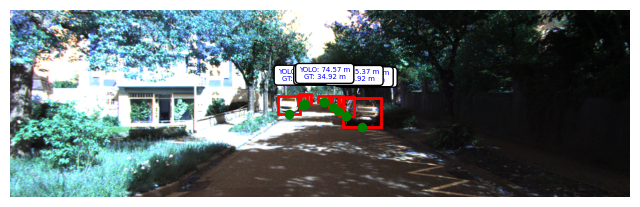

In [3]:
overall_count = 0
for i in [6037]:
    root = "F:/notes/Masters- Mechatronics/Computer Vision/Task 2/KITTI_Selection"
    img = cv2.imread(f"{root}/images/{i:06d}.png")
    calib = np.loadtxt(f"{root}/calib/{i:06d}.txt")
    #data = pd.read_csv(f"{root}/labels/{i:06d}.txt")
    datas = np.genfromtxt(f"{root}/labels/{i:06d}.txt")
    data = datas[:,-1]
    gt = sorted(data)
    results = model.predict(img, classes=[2])
    cars = []
    distance = []
    nearest = []
    for r in results:
        boxes = r.boxes.cpu().numpy()
        boxes = boxes.xyxy.tolist()
        for box in boxes: 
            x1, y1, x2, y2 = box[0], box[1], box[2], box[3]
            cars.append((x1, y1, x2, y2))
        # Display image with bounding box
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        for (x1, y1, x2, y2) in cars:
                w, h = abs(x2 - x1), abs(y2 - y1)
                bbox = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='r', facecolor='none')    
                plt.gca().add_patch(bbox)
                mx, my = (x1+ (w/2)), (y1+h)
                plt.plot(mx, my, 'go')
               # Example calibration matrix (replace with actual calibration matrix)
                calibration_matrix = np.array(calib)
                
                # Example pixel coordinates (replace with actual pixel coordinates)
                pixel_coordinates = np.array([[mx], [my]])
                
                inverse_calibration_matrix = np.linalg.inv(calibration_matrix)
                
                # Homogeneous coordinate transformation
                pixel_coordinates_homogeneous = np.vstack((pixel_coordinates, 1))
                
                # Compute world coordinates
                wch = np.dot(inverse_calibration_matrix, pixel_coordinates_homogeneous)
                y_ = 1.65/wch[1]
                x,y,z=(wch[0]*y_),1.65,(wch[2]*y_)
                distances = math.sqrt(x**2 + y**2 + z**2 )
                distance.append(distances)
                absolute_differences = [abs(x - distances) for x in gt]            
                nearest_index = absolute_differences.index(min(absolute_differences))            
                nearest_value = gt[nearest_index]
                nearest.append(nearest_value)           
                #del gt[nearest_index]
                
                plt.text(x1+50,y1-30, f"YOLO: {distances:.2f} m\nGT: {nearest_value:.2f} m", ha='center',fontsize=5, color='blue', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
     
    output_path='F:/notes/Masters- Mechatronics/Computer Vision/Task 2/results_Nahush/{}_updated.jpg'.format(overall_count)
    plt.axis('off')
    plt.savefig(output_path,dpi=1200,bbox_inches='tight',pad_inches=0 )
    overall_count=overall_count+1
    print(overall_count) 
    
